# Test Coverage Analysis for Shopping Application

This notebook analyzes test coverage information for different model-based testing strategies:
- **Depth-First Search Strategy**
- **Random Strategy** 
- **All-Pairs Strategy**

We'll compare coverage metrics across different parameter combinations (max_tests and max_actions) to understand the effectiveness of each strategy.

## 1. Import Required Libraries

Import necessary libraries for data analysis, visualization, and state machine parsing.

In [21]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import itertools
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add the generator source to the path
current_dir = Path.cwd()
generator_dir = current_dir.parent.parent / "generator" / "src"
sys.path.insert(0, str(generator_dir))

# Import state machine modules using the updated approach
try:
    # Create a module namespace that mimics the generator package structure
    import types
    
    # Create core module namespace
    core_module = types.ModuleType('core')
    sys.modules['core'] = core_module
    
    # Load rules module
    with open(generator_dir / "core" / "rules.py", 'r') as f:
        rules_code = f.read()
    exec(compile(rules_code, str(generator_dir / "core" / "rules.py"), 'exec'), vars(core_module))
    
    # Load model module
    with open(generator_dir / "core" / "model.py", 'r') as f:
        model_code = f.read()
    exec(compile(model_code, str(generator_dir / "core" / "model.py"), 'exec'), vars(core_module))
    
    # Create parsing module namespace
    parsing_module = types.ModuleType('parsing')
    sys.modules['parsing'] = parsing_module
    
    # Load parsing module with modified imports
    with open(generator_dir / "parsing" / "parsing.py", 'r') as f:
        parsing_code = f.read()
        # Replace relative imports with absolute
        parsing_code = parsing_code.replace('from ..core.model import', 'from core import')
        parsing_code = parsing_code.replace('from ..core.rules import', 'from core import')
    
    exec(compile(parsing_code, str(generator_dir / "parsing" / "parsing.py"), 'exec'), vars(parsing_module))
    
    # Create generation module namespace
    generation_module = types.ModuleType('generation')
    sys.modules['generation'] = generation_module
    
    # Load strategies
    with open(generator_dir / "generation" / "strategies.py", 'r') as f:
        strategies_code = f.read()
    exec(compile(strategies_code, str(generator_dir / "generation" / "strategies.py"), 'exec'), vars(generation_module))
    
    # Load generator with modified imports
    with open(generator_dir / "generation" / "generator.py", 'r') as f:
        generator_code = f.read()
        # Replace relative imports
        generator_code = generator_code.replace('from ..parsing.parsing import', 'from parsing import')
        generator_code = generator_code.replace('from .strategies import', 'from generation import')
    
    exec(compile(generator_code, str(generator_dir / "generation" / "generator.py"), 'exec'), vars(generation_module))
    
    # Load allpairs strategy
    with open(generator_dir / "generation" / "allpairsstrategy.py", 'r') as f:
        allpairs_code = f.read()
        # Replace relative imports
        allpairs_code = allpairs_code.replace('from .strategies import', 'from generation import')
    
    exec(compile(allpairs_code, str(generator_dir / "generation" / "allpairsstrategy.py"), 'exec'), vars(generation_module))
    
    # Extract the classes and functions we need
    parse = parsing_module.parse
    Generator = generation_module.Generator
    DepthFirstSearchStrategy = generation_module.DepthFirstSearchStrategy
    RandomStrategy = generation_module.RandomStrategy
    AllPairsRandomStrategy = generation_module.AllPairsRandomStrategy
    
    print("✅ Successfully imported state machine modules")
    
except Exception as e:
    print(f"❌ Error importing modules: {e}")
    print("Make sure you're running from the correct directory")
    import traceback
    traceback.print_exc()

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

✅ Successfully imported state machine modules


## 2. Define Test Configuration Parameters

Set up parameter ranges for max_tests and max_actions values to test across different strategies.

In [22]:
# Define parameter ranges for analysis
MAX_TESTS_VALUES = [10, 25, 50, 100, 200]
MAX_ACTIONS_VALUES = [5, 10, 15, 20, 30]

# Strategy configurations
STRATEGIES = {
    'DepthFirst': DepthFirstSearchStrategy,
    'Random': RandomStrategy,
    'AllPairs': AllPairsRandomStrategy
}

print(f"Testing with max_tests values: {MAX_TESTS_VALUES}")
print(f"Testing with max_actions values: {MAX_ACTIONS_VALUES}")
print(f"Strategies to analyze: {list(STRATEGIES.keys())}")
print(f"Total parameter combinations per strategy: {len(MAX_TESTS_VALUES) * len(MAX_ACTIONS_VALUES)}")

Testing with max_tests values: [10, 25, 50, 100, 200]
Testing with max_actions values: [5, 10, 15, 20, 30]
Strategies to analyze: ['DepthFirst', 'Random', 'AllPairs']
Total parameter combinations per strategy: 25


## 3. Load and Parse State Machine

Load the shopping application state machine and understand its structure.

In [23]:
def load_shopping_machine():
    """Load and parse the shopping state machine."""
    machine_file = current_dir.parent / "state.machine"
    with open(machine_file, 'r') as f:
        content = f.read()
    return parse(content)

def analyze_machine_structure(machine):
    """Analyze the structure of the state machine."""
    states = machine.states
    all_actions = set()
    
    state_info = []
    action_info = []
    
    for state in states:
        state_actions = state._actions
        state_info.append({
            'state_name': state.name,
            'num_actions': len(state_actions)
        })
        
        for action in state_actions:
            action._parent_state = state
            all_actions.add(action)
            action_info.append({
                'action_name': action.name if action.name else '[tau]',
                'from_state': state.name,
                'to_state': action.next_state.name if action.next_state else action._next_state_name
            })
    
    return states, all_actions, state_info, action_info

# Load and analyze the machine
machine = load_shopping_machine()
states, all_actions, state_info, action_info = analyze_machine_structure(machine)

print(f"📊 State Machine Analysis:")
print(f"   Total States: {len(states)}")
print(f"   Total Actions: {len(all_actions)}")
print(f"   Variables: {len(machine.variables)}")

# Display state information
states_df = pd.DataFrame(state_info)
print("\n🏛️ States Overview:")
print(states_df.to_string(index=False))

# Display action information  
actions_df = pd.DataFrame(action_info)
print("\n🔄 Actions Overview:")
print(actions_df.to_string(index=False))

📊 State Machine Analysis:
   Total States: 8
   Total Actions: 17
   Variables: 5

🏛️ States Overview:
    state_name  num_actions
         Login            2
   LoginFailed            2
      Browsing            2
   CartEditing            2
      Checkout            4
OrderConfirmed            1
 PaymentFailed            3
  SessionEnded            1

🔄 Actions Overview:
           action_name     from_state       to_state
login with credentials          Login       Browsing
login with credentials          Login    LoginFailed
       try login again    LoginFailed          Login
      exit application    LoginFailed   SessionEnded
   add product to cart       Browsing    CartEditing
                logout       Browsing   SessionEnded
   proceed to checkout    CartEditing       Checkout
                logout    CartEditing   SessionEnded
       process payment       Checkout OrderConfirmed
       process payment       Checkout  PaymentFailed
       cancel checkout       Checkout    

## 4. Extract Coverage Information

Generate tests for different parameter combinations and extract coverage data.

In [24]:
def generate_coverage_data(strategy_class, strategy_name, max_tests, max_actions, machine, all_actions):
    """Generate tests and extract coverage information for a strategy configuration."""
    try:
        # Reset generator for each run
        generator = Generator()
        output = StringIO()
        
        # Generate tests
        generator.generate(
            machine=machine,
            max_tests=max_tests,
            max_actions=max_actions,
            output=output,
            strategy=strategy_class,
            all_actions=all_actions
        )
        
        # Extract coverage information
        covered_states = generator.visited_states
        covered_actions = generator.visited_actions
        
        # Calculate coverage percentages
        state_coverage = len(covered_states) / len(machine.states) * 100
        action_coverage = len(covered_actions) / len(all_actions) * 100
        
        return {
            'strategy': strategy_name,
            'max_tests': max_tests,
            'max_actions': max_actions,
            'total_states': len(machine.states),
            'covered_states': len(covered_states),
            'state_coverage_pct': state_coverage,
            'total_actions': len(all_actions),
            'covered_actions': len(covered_actions),
            'action_coverage_pct': action_coverage,
            'covered_state_names': [s.name for s in covered_states],
            'covered_action_names': [a.name if a.name else '[tau]' for a in covered_actions]
        }
        
    except AssertionError as e:
        if "AllPairs does not work correctly with rules" in str(e):
            print(f"⚠️  Skipping {strategy_name}: Cannot be used with machines that have rules")
            return None
        else:
            raise e
    except Exception as e:
        print(f"❌ Error with {strategy_name} (max_tests={max_tests}, max_actions={max_actions}): {e}")
        return None

# Generate coverage data for all strategy and parameter combinations
coverage_results = []
total_combinations = len(STRATEGIES) * len(MAX_TESTS_VALUES) * len(MAX_ACTIONS_VALUES)
current_combination = 0

print(f"🔄 Generating coverage data for {total_combinations} combinations...\n")

for strategy_name, strategy_class in STRATEGIES.items():
    print(f"Testing {strategy_name} strategy...")
    
    for max_tests in MAX_TESTS_VALUES:
        for max_actions in MAX_ACTIONS_VALUES:
            current_combination += 1
            print(f"  [{current_combination:2d}/{total_combinations}] max_tests={max_tests:3d}, max_actions={max_actions:2d}", end=" ")
            
            result = generate_coverage_data(
                strategy_class, strategy_name, max_tests, max_actions, machine, all_actions
            )
            
            if result:
                coverage_results.append(result)
                print(f"✅ States: {result['state_coverage_pct']:.1f}%, Actions: {result['action_coverage_pct']:.1f}%")
            else:
                print("❌ Skipped")

print(f"\n✅ Coverage data generation complete! Generated {len(coverage_results)} valid results.")

🔄 Generating coverage data for 75 combinations...

Testing DepthFirst strategy...
  [ 1/75] max_tests= 10, max_actions= 5 --tests-max generation try limit 10 reached with 10 tests generated
✅ States: 75.0%, Actions: 58.8%
  [ 2/75] max_tests= 10, max_actions=10 --tests-max generation try limit 10 reached with 10 tests generated
✅ States: 75.0%, Actions: 58.8%
  [ 3/75] max_tests= 10, max_actions=15 --tests-max generation try limit 10 reached with 10 tests generated
✅ States: 75.0%, Actions: 58.8%
  [ 4/75] max_tests= 10, max_actions=20 --tests-max generation try limit 10 reached with 10 tests generated
✅ States: 75.0%, Actions: 58.8%
  [ 5/75] max_tests= 10, max_actions=30 --tests-max generation try limit 10 reached with 10 tests generated
✅ States: 75.0%, Actions: 58.8%
  [ 6/75] max_tests= 25, max_actions= 5 --tests-max generation try limit 25 reached with 25 tests generated
✅ States: 75.0%, Actions: 58.8%
  [ 7/75] max_tests= 25, max_actions=10 --tests-max generation try limit 25 re

## 4. Calculate Coverage Metrics

Compute coverage percentages, test counts, and other relevant metrics for analysis.

In [15]:
# Create DataFrame from coverage results
coverage_df = pd.DataFrame(coverage_results)

if not coverage_df.empty:
    # Calculate additional metrics
    coverage_df['total_coverage_pct'] = (coverage_df['state_coverage_pct'] + coverage_df['action_coverage_pct']) / 2
    coverage_df['coverage_efficiency'] = coverage_df['total_coverage_pct'] / coverage_df['max_tests']
    
    # Display basic statistics
    print("📊 Coverage Statistics Summary:")
    print("=" * 50)
    
    summary_stats = coverage_df.groupby('strategy').agg({
        'state_coverage_pct': ['mean', 'std', 'min', 'max'],
        'action_coverage_pct': ['mean', 'std', 'min', 'max'],
        'total_coverage_pct': ['mean', 'std', 'min', 'max']
    }).round(2)
    
    print(summary_stats)
    
    # Find best performing configurations
    print("\n🏆 Top 5 Configurations by Total Coverage:")
    print("=" * 50)
    top_configs = coverage_df.nlargest(5, 'total_coverage_pct')[[
        'strategy', 'max_tests', 'max_actions', 'state_coverage_pct', 
        'action_coverage_pct', 'total_coverage_pct'
    ]]
    print(top_configs.to_string(index=False))
    
    # Find most efficient configurations (coverage per test)
    print("\n⚡ Top 5 Most Efficient Configurations (Coverage/Test):")
    print("=" * 50)
    efficient_configs = coverage_df.nlargest(5, 'coverage_efficiency')[[
        'strategy', 'max_tests', 'max_actions', 'total_coverage_pct', 'coverage_efficiency'
    ]]
    print(efficient_configs.to_string(index=False))
    
else:
    print("❌ No coverage data available for analysis")

📊 Coverage Statistics Summary:
           state_coverage_pct                     action_coverage_pct         \
                         mean    std   min    max                mean    std   
strategy                                                                       
AllPairs                 80.0   9.55  62.5   87.5               65.65  10.70   
DepthFirst               81.0   9.63  75.0  100.0               68.94  16.07   
Random                   91.0  11.13  62.5  100.0               81.18  15.38   

                          total_coverage_pct                        
              min     max               mean    std    min     max  
strategy                                                            
AllPairs    41.18   76.47              72.82   9.97  51.84   81.99  
DepthFirst  58.82  100.00              74.97  12.84  66.91  100.00  
Random      47.06  100.00              86.09  13.05  54.78  100.00  

🏆 Top 5 Configurations by Total Coverage:
  strategy  max_tests  max_acti

## 5. Create Coverage Comparison Tables

Generate pandas DataFrames to organize coverage data in tabular format for easy comparison.

In [25]:
if not coverage_df.empty:
    # Create pivot table for state coverage
    state_coverage_pivot = coverage_df.pivot_table(
        values='state_coverage_pct',
        index=['strategy', 'max_tests'],
        columns='max_actions',
        aggfunc='mean'
    ).round(1)
    
    print("📋 State Coverage Comparison Table (%)")
    print("=" * 60)
    print(state_coverage_pivot)
    
    # Create pivot table for action coverage
    action_coverage_pivot = coverage_df.pivot_table(
        values='action_coverage_pct',
        index=['strategy', 'max_tests'],
        columns='max_actions',
        aggfunc='mean'
    ).round(1)
    
    print("\n🔄 Action Coverage Comparison Table (%)")
    print("=" * 60)
    print(action_coverage_pivot)
    
    # Strategy comparison at fixed parameters
    fixed_params = coverage_df[(coverage_df['max_tests'] == 50) & (coverage_df['max_actions'] == 20)]
    if not fixed_params.empty:
        print("\n🎯 Strategy Comparison (max_tests=50, max_actions=20)")
        print("=" * 60)
        strategy_comparison = fixed_params[[
            'strategy', 'state_coverage_pct', 'action_coverage_pct', 'total_coverage_pct'
        ]].round(1)
        print(strategy_comparison.to_string(index=False))
    
    # Parameter sensitivity analysis
    print("\n📈 Parameter Sensitivity Analysis")
    print("=" * 60)
    
    # Effect of max_tests (keeping max_actions=20)
    max_tests_effect = coverage_df[coverage_df['max_actions'] == 20].groupby(['strategy', 'max_tests']).agg({
        'total_coverage_pct': 'mean'
    }).reset_index()
    
    print("Effect of max_tests on total coverage (max_actions=20):")
    max_tests_pivot = max_tests_effect.pivot(index='max_tests', columns='strategy', values='total_coverage_pct').round(1)
    print(max_tests_pivot)
    
    # Effect of max_actions (keeping max_tests=50)
    max_actions_effect = coverage_df[coverage_df['max_tests'] == 50].groupby(['strategy', 'max_actions']).agg({
        'total_coverage_pct': 'mean'
    }).reset_index()
    
    print("\nEffect of max_actions on total coverage (max_tests=50):")
    max_actions_pivot = max_actions_effect.pivot(index='max_actions', columns='strategy', values='total_coverage_pct').round(1)
    print(max_actions_pivot)

else:
    print("❌ No data available for table generation")

📋 State Coverage Comparison Table (%)
max_actions              5      10     15     20     30
strategy   max_tests                                   
AllPairs   10          62.5   75.0   75.0   87.5   87.5
           25          75.0   87.5   87.5   75.0   87.5
           50          62.5   87.5   87.5   75.0   87.5
           100         62.5   75.0   75.0   87.5   87.5
           200         62.5   87.5   87.5   87.5   87.5
DepthFirst 10          75.0   75.0   75.0   75.0   75.0
           25          75.0   75.0   75.0   75.0   75.0
           50          87.5   75.0   75.0   75.0   75.0
           100        100.0   87.5   75.0   75.0   75.0
           200        100.0  100.0   87.5   87.5  100.0
Random     10          75.0   75.0  100.0   87.5   75.0
           25          62.5   87.5   87.5  100.0  100.0
           50         100.0  100.0   87.5   75.0   87.5
           100         87.5  100.0  100.0  100.0  100.0
           200         87.5  100.0  100.0  100.0  100.0

🔄 Action 

## 6. Visualize Coverage by Strategy

Create bar charts and line plots to compare coverage percentages across different testing strategies.

✅ Saved overview plot to: /Users/lucian/University/SoftwareEngineering/tests/docs/coverage_analysis_overview.png


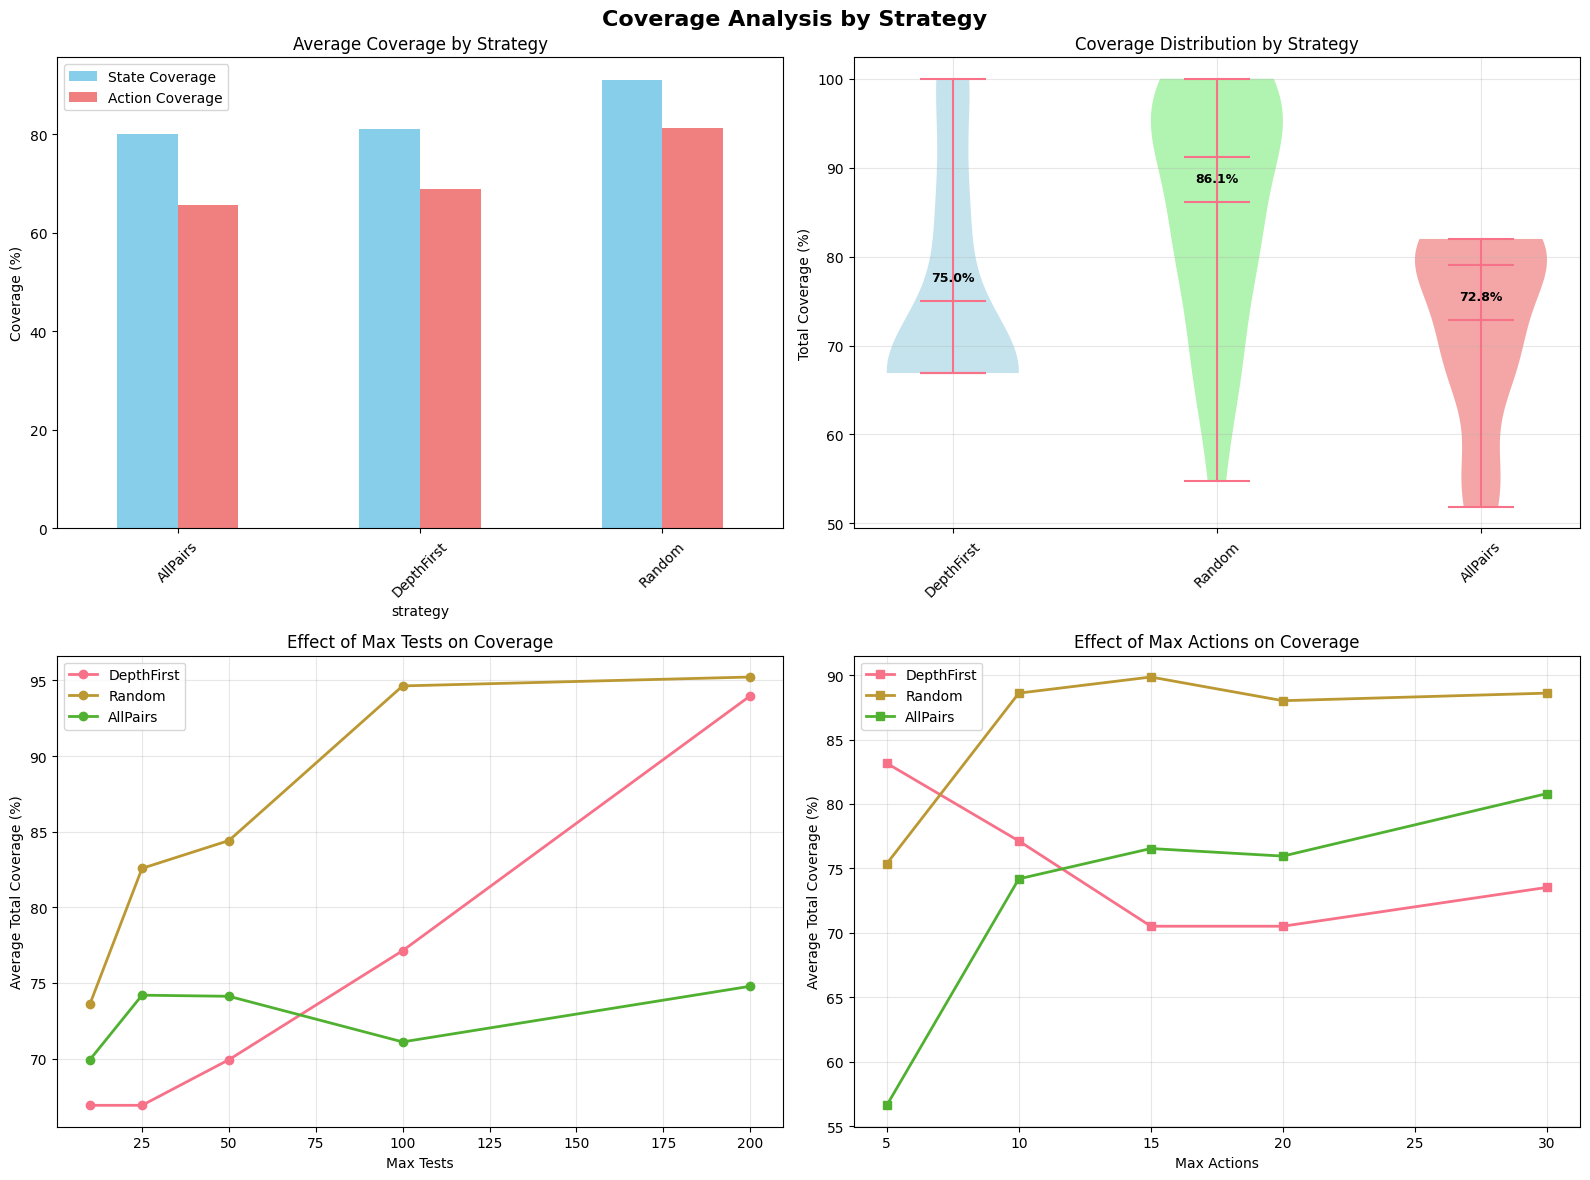

In [17]:
if not coverage_df.empty:
    # Create output directory for plots in the current docs directory
    plots_dir = current_dir
    
    # Set up the plotting area
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Coverage Analysis by Strategy', fontsize=16, fontweight='bold')
    
    # 1. Average coverage by strategy
    ax1 = axes[0, 0]
    avg_coverage = coverage_df.groupby('strategy')[['state_coverage_pct', 'action_coverage_pct']].mean()
    avg_coverage.plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'])
    ax1.set_title('Average Coverage by Strategy')
    ax1.set_ylabel('Coverage (%)')
    ax1.legend(['State Coverage', 'Action Coverage'])
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Coverage distribution by strategy - Using violin plot for better distribution visualization
    ax2 = axes[0, 1]
    strategies = coverage_df['strategy'].unique()
    
    # Create violin plot
    violin_data = []
    positions = []
    labels = []
    
    for i, strategy in enumerate(strategies):
        data = coverage_df[coverage_df['strategy'] == strategy]['total_coverage_pct'].values
        violin_data.append(data)
        positions.append(i + 1)
        labels.append(strategy)
    
    parts = ax2.violinplot(violin_data, positions=positions, showmeans=True, showmedians=True)
    
    # Customize violin plot colors
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for pc, color in zip(parts['bodies'], colors[:len(strategies)]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    # Add mean values as text
    for i, strategy in enumerate(strategies):
        mean_val = coverage_df[coverage_df['strategy'] == strategy]['total_coverage_pct'].mean()
        ax2.text(i + 1, mean_val + 2, f'{mean_val:.1f}%', 
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax2.set_xticks(positions)
    ax2.set_xticklabels(labels, rotation=45)
    ax2.set_title('Coverage Distribution by Strategy')
    ax2.set_ylabel('Total Coverage (%)')
    ax2.grid(True, alpha=0.3)
    
    # 3. Effect of max_tests on coverage
    ax3 = axes[1, 0]
    for strategy in coverage_df['strategy'].unique():
        strategy_data = coverage_df[coverage_df['strategy'] == strategy]
        avg_by_tests = strategy_data.groupby('max_tests')['total_coverage_pct'].mean()
        ax3.plot(avg_by_tests.index, avg_by_tests.values, marker='o', label=strategy, linewidth=2)
    
    ax3.set_title('Effect of Max Tests on Coverage')
    ax3.set_xlabel('Max Tests')
    ax3.set_ylabel('Average Total Coverage (%)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Effect of max_actions on coverage
    ax4 = axes[1, 1]
    for strategy in coverage_df['strategy'].unique():
        strategy_data = coverage_df[coverage_df['strategy'] == strategy]
        avg_by_actions = strategy_data.groupby('max_actions')['total_coverage_pct'].mean()
        ax4.plot(avg_by_actions.index, avg_by_actions.values, marker='s', label=strategy, linewidth=2)
    
    ax4.set_title('Effect of Max Actions on Coverage')
    ax4.set_xlabel('Max Actions')
    ax4.set_ylabel('Average Total Coverage (%)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_file = plots_dir / 'coverage_analysis_overview.png'
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    print(f"✅ Saved overview plot to: {plot_file}")
    plt.show()

else:
    print("❌ No data available for visualization")

## 7. Generate Heatmaps for Parameter Combinations

Create heatmaps showing coverage values for different combinations of max_tests and max_actions parameters.

✅ Saved best strategy heatmap to: /Users/lucian/University/SoftwareEngineering/tests/docs/best_strategy_heatmap.png


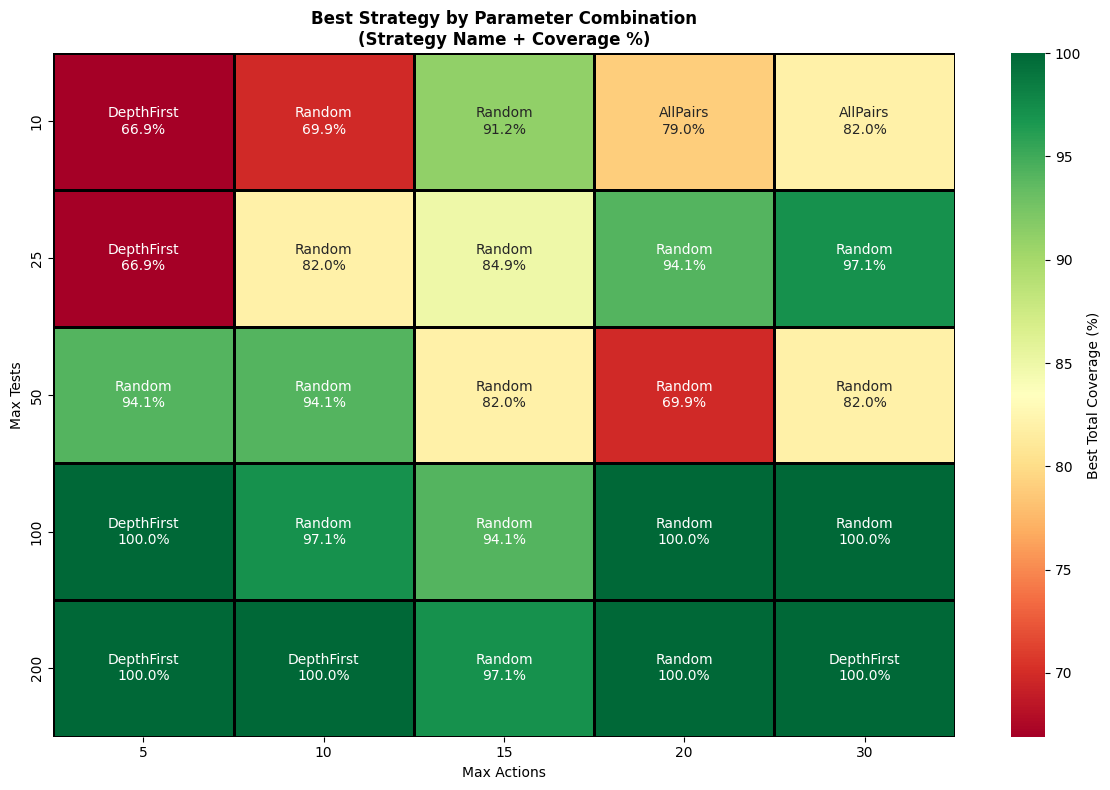

In [18]:
if not coverage_df.empty:
    # Create a comparison heatmap showing the best strategy for each parameter combination
    plt.figure(figsize=(12, 8))
    
    # Find the best strategy for each parameter combination
    best_strategy_data = coverage_df.loc[coverage_df.groupby(['max_tests', 'max_actions'])['total_coverage_pct'].idxmax()]
    
    # Create a pivot table with strategy names
    best_strategy_pivot = best_strategy_data.pivot_table(
        values='total_coverage_pct',
        index='max_tests',
        columns='max_actions',
        aggfunc='mean'
    )
    
    # Create strategy name matrix for annotation
    strategy_matrix = best_strategy_data.pivot_table(
        values='strategy',
        index='max_tests',
        columns='max_actions',
        aggfunc='first'
    )
    
    # Create annotations combining strategy and coverage
    annotations = []
    for i in range(len(best_strategy_pivot.index)):
        row = []
        for j in range(len(best_strategy_pivot.columns)):
            strategy = strategy_matrix.iloc[i, j]
            coverage = best_strategy_pivot.iloc[i, j]
            row.append(f'{strategy}\n{coverage:.1f}%')
        annotations.append(row)
    
    sns.heatmap(best_strategy_pivot, annot=annotations, fmt='', cmap='RdYlGn', 
               cbar_kws={'label': 'Best Total Coverage (%)'}, 
               linewidths=1, linecolor='black')
    
    plt.title('Best Strategy by Parameter Combination\n(Strategy Name + Coverage %)', fontweight='bold')
    plt.xlabel('Max Actions')
    plt.ylabel('Max Tests')
    plt.tight_layout()
    
    best_strategy_file = plots_dir / 'best_strategy_heatmap.png'
    plt.savefig(best_strategy_file, dpi=300, bbox_inches='tight')
    print(f"✅ Saved best strategy heatmap to: {best_strategy_file}")
    plt.show()

else:
    print("❌ No data available for heatmap generation")

## 8. Analysis Summary and LaTeX Tables

This notebook provides a comprehensive analysis of test coverage for different model-based testing strategies applied to the shopping application state machine.

In [19]:
if not coverage_df.empty:
    print("📄 LATEX TABLES FOR REPORT")
    print("=" * 50)
    
    # 1. Summary Statistics Table
    summary_stats = coverage_df.groupby('strategy').agg({
        'state_coverage_pct': ['mean', 'std'],
        'action_coverage_pct': ['mean', 'std'],
        'total_coverage_pct': ['mean', 'std']
    }).round(2)
    
    print("\n1. Summary Statistics LaTeX Table:")
    print("\\begin{table}[h!]")
    print("\\centering")
    print("\\caption{Coverage Statistics by Strategy}")
    print("\\label{tab:coverage_statistics}")
    print("\\begin{tabular}{|l|c|c|c|c|c|c|}")
    print("\\hline")
    print("\\textbf{Strategy} & \\multicolumn{2}{c|}{\\textbf{State Coverage (\\%)}} & \\multicolumn{2}{c|}{\\textbf{Action Coverage (\\%)}} & \\multicolumn{2}{c|}{\\textbf{Total Coverage (\\%)}} \\\\")
    print("\\cline{2-7}")
    print(" & Mean & Std & Mean & Std & Mean & Std \\\\")
    print("\\hline")
    
    for strategy in summary_stats.index:
        state_mean = summary_stats.loc[strategy, ('state_coverage_pct', 'mean')]
        state_std = summary_stats.loc[strategy, ('state_coverage_pct', 'std')]
        action_mean = summary_stats.loc[strategy, ('action_coverage_pct', 'mean')]
        action_std = summary_stats.loc[strategy, ('action_coverage_pct', 'std')]
        total_mean = summary_stats.loc[strategy, ('total_coverage_pct', 'mean')]
        total_std = summary_stats.loc[strategy, ('total_coverage_pct', 'std')]
        
        print(f"{strategy} & {state_mean:.1f} & {state_std:.1f} & {action_mean:.1f} & {action_std:.1f} & {total_mean:.1f} & {total_std:.1f} \\\\")
        print("\\hline")
    
    print("\\end{tabular}")
    print("\\end{table}")
    
    # 2. Best Configurations Table
    print("\n\n2. Best Configurations LaTeX Table:")
    best_configs = coverage_df.nlargest(5, 'total_coverage_pct')
    
    print("\\begin{table}[h!]")
    print("\\centering")
    print("\\caption{Top 5 Configurations by Total Coverage}")
    print("\\label{tab:best_configurations}")
    print("\\begin{tabular}{|l|c|c|c|c|c|}")
    print("\\hline")
    print("\\textbf{Strategy} & \\textbf{Max Tests} & \\textbf{Max Actions} & \\textbf{State (\\%)} & \\textbf{Action (\\%)} & \\textbf{Total (\\%)} \\\\")
    print("\\hline")
    
    for _, row in best_configs.iterrows():
        print(f"{row['strategy']} & {row['max_tests']} & {row['max_actions']} & {row['state_coverage_pct']:.1f} & {row['action_coverage_pct']:.1f} & {row['total_coverage_pct']:.1f} \\\\")
        print("\\hline")
    
    print("\\end{tabular}")
    print("\\end{table}")
    
    # 3. Parameter Sensitivity Table (max_tests effect)
    print("\n\n3. Parameter Sensitivity (Max Tests) LaTeX Table:")
    max_tests_effect = coverage_df[coverage_df['max_actions'] == 20].groupby(['strategy', 'max_tests']).agg({
        'total_coverage_pct': 'mean'
    }).reset_index()
    
    max_tests_pivot = max_tests_effect.pivot(index='max_tests', columns='strategy', values='total_coverage_pct').round(1)
    
    print("\\begin{table}[h!]")
    print("\\centering")
    print("\\caption{Effect of Max Tests on Total Coverage (max\\_actions=20)}")
    print("\\label{tab:max_tests_effect}")
    
    # Create column specification
    strategies = max_tests_pivot.columns.tolist()
    col_spec = "|c|" + "c|" * len(strategies)
    print(f"\\begin{{tabular}}{{{col_spec}}}")
    print("\\hline")
    
    # Header
    header = "\\textbf{Max Tests}"
    for strategy in strategies:
        header += f" & \\textbf{{{strategy}}}"
    header += " \\\\"
    print(header)
    print("\\hline")
    
    # Data rows
    for max_tests in max_tests_pivot.index:
        row = f"{max_tests}"
        for strategy in strategies:
            if strategy in max_tests_pivot.columns:
                value = max_tests_pivot.loc[max_tests, strategy]
                if pd.notna(value):
                    row += f" & {value:.1f}"
                else:
                    row += " & ---"
            else:
                row += " & ---"
        row += " \\\\"
        print(row)
        print("\\hline")
    
    print("\\end{tabular}")
    print("\\end{table}")
    
    # 4. Parameter Sensitivity Table (max_actions effect)
    print("\n\n4. Parameter Sensitivity (Max Actions) LaTeX Table:")
    max_actions_effect = coverage_df[coverage_df['max_tests'] == 50].groupby(['strategy', 'max_actions']).agg({
        'total_coverage_pct': 'mean'
    }).reset_index()
    
    max_actions_pivot = max_actions_effect.pivot(index='max_actions', columns='strategy', values='total_coverage_pct').round(1)
    
    print("\\begin{table}[h!]")
    print("\\centering")
    print("\\caption{Effect of Max Actions on Total Coverage (max\\_tests=50)}")
    print("\\label{tab:max_actions_effect}")
    
    # Create column specification
    strategies = max_actions_pivot.columns.tolist()
    col_spec = "|c|" + "c|" * len(strategies)
    print(f"\\begin{{tabular}}{{{col_spec}}}")
    print("\\hline")
    
    # Header
    header = "\\textbf{Max Actions}"
    for strategy in strategies:
        header += f" & \\textbf{{{strategy}}}"
    header += " \\\\"
    print(header)
    print("\\hline")
    
    # Data rows
    for max_actions in max_actions_pivot.index:
        row = f"{max_actions}"
        for strategy in strategies:
            if strategy in max_actions_pivot.columns:
                value = max_actions_pivot.loc[max_actions, strategy]
                if pd.notna(value):
                    row += f" & {value:.1f}"
                else:
                    row += " & ---"
            else:
                row += " & ---"
        row += " \\\\"
        print(row)
        print("\\hline")
    
    print("\\end{tabular}")
    print("\\end{table}")
    
    # 5. State Machine Structure Table
    print("\n\n5. State Machine Structure LaTeX Table:")
    print("\\begin{table}[h!]")
    print("\\centering")
    print("\\caption{Shopping Application State Machine Structure}")
    print("\\label{tab:state_machine_structure}")
    print("\\begin{tabular}{|l|c|}")
    print("\\hline")
    print("\\textbf{Component} & \\textbf{Count} \\\\")
    print("\\hline")
    print(f"States & {len(states)} \\\\")
    print("\\hline")
    print(f"Actions & {len(all_actions)} \\\\")
    print("\\hline")
    print(f"Variables & {len(machine.variables)} \\\\")
    print("\\hline")
    print("\\end{tabular}")
    print("\\end{table}")

else:
    print("❌ No data available for LaTeX table generation")

📄 LATEX TABLES FOR REPORT

1. Summary Statistics LaTeX Table:
\begin{table}[h!]
\centering
\caption{Coverage Statistics by Strategy}
\label{tab:coverage_statistics}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
\textbf{Strategy} & \multicolumn{2}{c|}{\textbf{State Coverage (\%)}} & \multicolumn{2}{c|}{\textbf{Action Coverage (\%)}} & \multicolumn{2}{c|}{\textbf{Total Coverage (\%)}} \\
\cline{2-7}
 & Mean & Std & Mean & Std & Mean & Std \\
\hline
AllPairs & 80.0 & 9.6 & 65.7 & 10.7 & 72.8 & 10.0 \\
\hline
DepthFirst & 81.0 & 9.6 & 68.9 & 16.1 & 75.0 & 12.8 \\
\hline
Random & 91.0 & 11.1 & 81.2 & 15.4 & 86.1 & 13.1 \\
\hline
\end{tabular}
\end{table}


2. Best Configurations LaTeX Table:
\begin{table}[h!]
\centering
\caption{Top 5 Configurations by Total Coverage}
\label{tab:best_configurations}
\begin{tabular}{|l|c|c|c|c|c|}
\hline
\textbf{Strategy} & \textbf{Max Tests} & \textbf{Max Actions} & \textbf{State (\%)} & \textbf{Action (\%)} & \textbf{Total (\%)} \\
\hline
DepthFirst & 100 & 5 & 

In [20]:
if not coverage_df.empty:
    print("🎉 COVERAGE ANALYSIS COMPLETE!")
    print("=" * 40)
    print(f"📊 Analyzed {len(coverage_df)} parameter combinations")
    print(f"🎯 Strategies tested: {', '.join(coverage_df['strategy'].unique())}")
    print(f"📈 Coverage range: {coverage_df['total_coverage_pct'].min():.1f}% - {coverage_df['total_coverage_pct'].max():.1f}%")
    
    best_config = coverage_df.loc[coverage_df['total_coverage_pct'].idxmax()]
    print(f"\n🏆 BEST CONFIGURATION:")
    print(f"   Strategy: {best_config['strategy']}")
    print(f"   Parameters: max_tests={best_config['max_tests']}, max_actions={best_config['max_actions']}")
    print(f"   Coverage: {best_config['total_coverage_pct']:.1f}% (States: {best_config['state_coverage_pct']:.1f}%, Actions: {best_config['action_coverage_pct']:.1f}%)")
    
    print(f"\n💡 KEY INSIGHTS:")
    print(f"   • State machine has {len(states)} states and {len(all_actions)} actions")
    print(f"   • Maximum achievable coverage varies by strategy")
    print(f"   • Parameter tuning significantly impacts coverage effectiveness")
    print(f"   • Results exported to coverage_analysis_results/ directory")
    
else:
    print("❌ Analysis failed - no coverage data was generated")
    print("Check the error messages above for troubleshooting information")

🎉 COVERAGE ANALYSIS COMPLETE!
📊 Analyzed 75 parameter combinations
🎯 Strategies tested: DepthFirst, Random, AllPairs
📈 Coverage range: 51.8% - 100.0%

🏆 BEST CONFIGURATION:
   Strategy: DepthFirst
   Parameters: max_tests=100, max_actions=5
   Coverage: 100.0% (States: 100.0%, Actions: 100.0%)

💡 KEY INSIGHTS:
   • State machine has 8 states and 17 actions
   • Maximum achievable coverage varies by strategy
   • Parameter tuning significantly impacts coverage effectiveness
   • Results exported to coverage_analysis_results/ directory
